In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import classification_report

In [2]:
# Read orgination data file and assign column names and display first rows
origination_df = pd.read_csv("data/sample_orig_2021.txt", delimiter = "|")
origination_df.columns = ['credit_score','first_payment_date','first_time_homebuyer_flag','maturity_date','msa','mortgage_insurance_percentage',
                     'num_units','occupancy_status','cltv_score','dti','upb','ltv','interest_rate','channel','ppm_flag','amortization_type','state',
                     'property_type','postal_code','Loan_Sequence_Number','loan_purpose','loan_term','num_borrowers','seller_name',
                     'servicer_name','super_conforming_flag','preharp_loan_sequence_number','p_indicator','harp_indicator','pvm','io_indicator',
                     'mortgage_ins_cancel_indicator'
]
num_rows = len(origination_df)
print(num_rows)

49999


In [3]:
# Read performance data file and assign column names and display first rows
performance_df = pd.read_csv("data/sample_svcg_2021.txt", delimiter = "|")
performance_df.columns = ['Loan_Sequence_Number','Monthly_Reporting_Period','Current_Actual_UPB','Current_Loan_Delinquency_Status','Loan_Age','Remaining_Months_to_Legal_Maturity',
 'Defect_Settlement_Date','Modification_Flag','Zero_Balance_Code','Zero_Balance_Effective_Date','Current_Interest_Rate','Current_Deferred_UPB',
 'Due_Date_of_Last_Paid_Installment','MI_Recoveries','Net_Sales_Proceeds','Non_MI_Recoveries','Expenses','Legal_Costs','Maintenance_and_Preservation_Costs',
 'Taxes_and_Insurance','Miscellaneous_Expenses','Actual_Loss_Calculation','Modification_Cost','Step_Modification_Flag','Deferred_Payment_Plan',
 'Estimated_Loan-to-Value','Zero_Balance_Removal_UPB','Delinquent_Accrued_Interest','Delinquency_Due_to_Disaster','Borrower_Assistance_Status_Code',
 'Current_Month_Modification_Cost','Interest_Bearing_UPB'
]
num_rows = len(performance_df)
print(num_rows)

C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\1147527660.py:2: DtypeWarning: Columns (3,7,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  performance_df = pd.read_csv("data/sample_svcg_2021.txt", delimiter = "|")


1913129


In [4]:
df_filtered = performance_df[performance_df ['Current_Loan_Delinquency_Status'] != 'RA']
df_filtered['Current_Loan_Delinquency_Status_int'] = df_filtered['Current_Loan_Delinquency_Status'].astype(int)

# Calculate Delinquency Flag 
def calculate_delinquency(row):
    if (row['Current_Loan_Delinquency_Status_int'] >= 3):
        delinquency_flag = 1
    else:
        delinquency_flag = 0
    return delinquency_flag

df_filtered['delinquency_flag'] = df_filtered.apply(calculate_delinquency, axis = 1)
display(df_filtered.head(5))

C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\3170105396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Current_Loan_Delinquency_Status_int'] = df_filtered['Current_Loan_Delinquency_Status'].astype(int)
C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\3170105396.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['delinquency_flag'] = df_filtered.apply(calculate_delinquency, axis = 1)


,Loan_Sequence_Number,Monthly_Reporting_Period,Current_Actual_UPB,Current_Loan_Delinquency_Status,Loan_Age,Remaining_Months_to_Legal_Maturity,Defect_Settlement_Date,Modification_Flag,Zero_Balance_Code,Zero_Balance_Effective_Date,...,Deferred_Payment_Plan,Estimated_Loan-to-Value,Zero_Balance_Removal_UPB,Delinquent_Accrued_Interest,Delinquency_Due_to_Disaster,Borrower_Assistance_Status_Code,Current_Month_Modification_Cost,Interest_Bearing_UPB,Current_Loan_Delinquency_Status_int,delinquency_flag
0,F21Q11275826,202103,68000.0,0,1,359,NaN,NaN,NaN,NaN,...,NaN,50,NaN,NaN,NaN,NaN,NaN,68000.0,0,0
1,F21Q11275826,202104,68000.0,0,2,358,NaN,NaN,NaN,NaN,...,NaN,49,NaN,NaN,NaN,NaN,NaN,68000.0,0,0
2,F21Q11275826,202105,68000.0,0,3,357,NaN,NaN,NaN,NaN,...,NaN,45,NaN,NaN,NaN,NaN,NaN,68000.0,0,0
3,F21Q11275826,202106,67000.0,0,4,356,NaN,NaN,NaN,NaN,...,NaN,44,NaN,NaN,NaN,NaN,NaN,67000.0,0,0
4,F21Q11275826,202107,67000.0,0,5,355,NaN,NaN,NaN,NaN,...,NaN,44,NaN,NaN,NaN,NaN,NaN,67000.0,0,0


In [5]:
# Inner join on a common column 'key'
merged_df = pd.merge(origination_df, df_filtered, on='Loan_Sequence_Number', how='inner')
num_rows = len(merged_df)
print("Rows in Merged Dataset ",num_rows)

# Sample data for graphs to run effectively
rows_to_sample = 1913039
sampled_df = merged_df.sample(n=rows_to_sample)
num_rows = len(sampled_df)
print("Rows in Sample Dataset ",num_rows)

Rows in Merged Dataset  1913039
Rows in Sample Dataset  1913039


In [6]:
# Feature engineering - Select features required for ML Model
features = ['Loan_Sequence_Number', 'Monthly_Reporting_Period','Current_Actual_UPB','credit_score', 'cltv_score', 
            'dti', 'interest_rate','mortgage_insurance_percentage', 'num_borrowers','delinquency_flag']
final_df = sampled_df[features]

print("Final dataframe created")

Final dataframe created


C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\290481884.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['dti_bin'] = pd.cut(final_df['dti'], bins=[0, 10, 20, 30, 40, 50, 60],
C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\290481884.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_group = final_df.groupby('dti_bin')['delinquency_flag'].mean().reset_index()


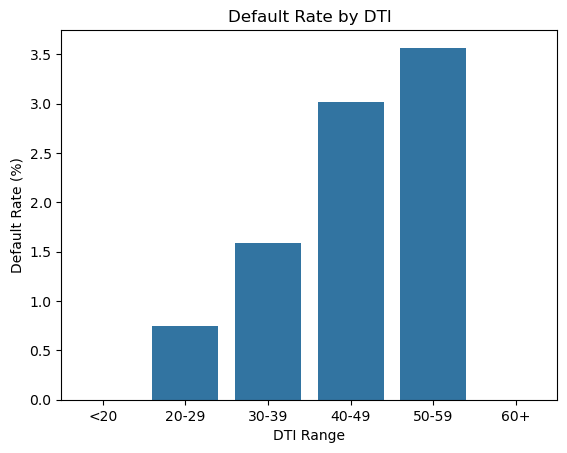

In [7]:
# Bin DTI into ranges
final_df['dti_bin'] = pd.cut(final_df['dti'], bins=[0, 10, 20, 30, 40, 50, 60], 
                             labels=['<20', '20-29', '30-39', '40-49', '50-59', '60+'])

# Group and calculate default rate
dti_group = final_df.groupby('dti_bin')['delinquency_flag'].mean().reset_index()
dti_group['default_rate'] = dti_group['delinquency_flag'] * 1000

# Plot
sns.barplot(data=dti_group, x='dti_bin', y='default_rate')
plt.title('Default Rate by DTI')
plt.xlabel('DTI Range')
plt.ylabel('Default Rate (%)')
plt.show()


<h5>Analysis: As the Debt-to-Income ratio increases in value (the borrower's debt gets proportionally higher than their income), the default rate increases.</h5>

C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\456585345.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['cltv_bin'] = pd.cut(final_df['cltv_score'], bins=[0, 60, 70, 80, 90, 100, 125],
C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\456585345.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cltv_group = final_df.groupby('cltv_bin')['delinquency_flag'].mean().reset_index()


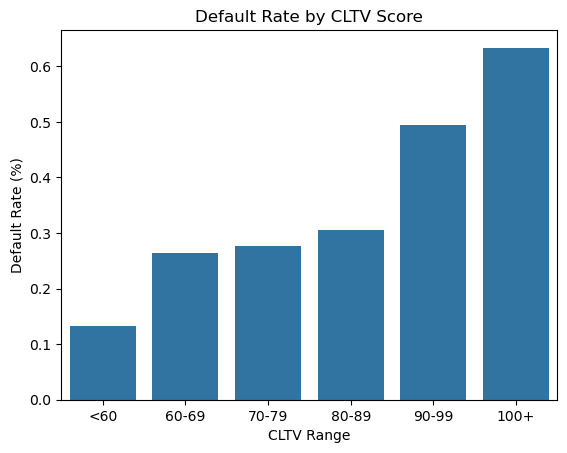

In [8]:
# Bin CLTV into ranges
final_df['cltv_bin'] = pd.cut(final_df['cltv_score'], bins=[0, 60, 70, 80, 90, 100, 125], 
                              labels=['<60', '60-69', '70-79', '80-89', '90-99', '100+'])

# Group and calculate default rate
cltv_group = final_df.groupby('cltv_bin')['delinquency_flag'].mean().reset_index()
cltv_group['default_rate'] = cltv_group['delinquency_flag'] * 100

# Plot
sns.barplot(data=cltv_group, x='cltv_bin', y='default_rate')
plt.title('Default Rate by CLTV Score')
plt.xlabel('CLTV Range')
plt.ylabel('Default Rate (%)')
plt.show()


<h5>Analysis: As Combined-Loan-to-Value ratio (the loan the borrower assumes with respect to the value of the property) increases, the default rate increases.</h5>

C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\4024045549.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['credit_score_bin'] = pd.cut(final_df['credit_score'], bins=[300, 600, 650, 700, 750, 800, 850],
C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\4024045549.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_group = final_df.groupby('credit_score_bin')['delinquency_flag'].mean().reset_index()


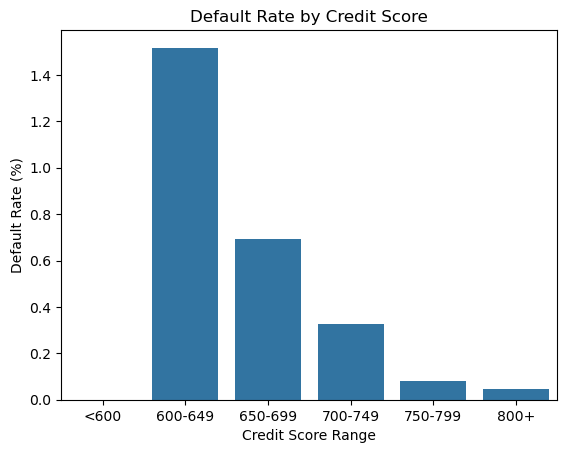

In [9]:
# Bin credit score
final_df['credit_score_bin'] = pd.cut(final_df['credit_score'], bins=[300, 600, 650, 700, 750, 800, 850],
                                      labels=['<600', '600-649', '650-699', '700-749', '750-799', '800+'])

# Group and calculate default rate
credit_group = final_df.groupby('credit_score_bin')['delinquency_flag'].mean().reset_index()
credit_group['default_rate'] = credit_group['delinquency_flag'] * 100

# Plot
sns.barplot(data=credit_group, x='credit_score_bin', y='default_rate')
plt.title('Default Rate by Credit Score')
plt.xlabel('Credit Score Range')
plt.ylabel('Default Rate (%)')
plt.show()


<h5>Analysis: As Credit Score increases, the default rate decreases.</h5>

C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\2458151408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['interest_rate_bin'] = pd.cut(final_df['interest_rate'], bins=[0, 2, 3, 4, 5, 6, 7, 10],
C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\2458151408.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interest_group = final_df.groupby('interest_rate_bin')['delinquency_flag'].mean().reset_index()


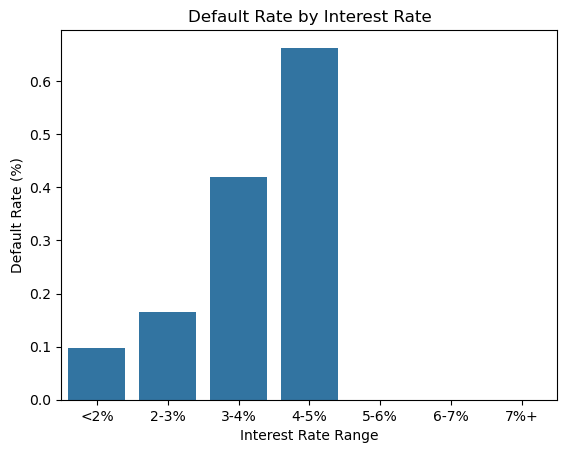

In [10]:
# Bin interest rate
final_df['interest_rate_bin'] = pd.cut(final_df['interest_rate'], bins=[0, 2, 3, 4, 5, 6, 7, 10],
                                       labels=['<2%', '2-3%', '3-4%', '4-5%', '5-6%', '6-7%', '7%+'])

# Group and calculate default rate
interest_group = final_df.groupby('interest_rate_bin')['delinquency_flag'].mean().reset_index()
interest_group['default_rate'] = interest_group['delinquency_flag'] * 100

# Plot
sns.barplot(data=interest_group, x='interest_rate_bin', y='default_rate')
plt.title('Default Rate by Interest Rate')
plt.xlabel('Interest Rate Range')
plt.ylabel('Default Rate (%)')
plt.show()


<h5>Analysis: As the interest rate increases, default rate increases</h5>

C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\637131903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['mi_bin'] = pd.cut(final_df['mortgage_insurance_percentage'], bins = range(0, 60, 10))  # e.g., 0-5%, 5-10%, ..., 55-60%
C:\Users\aadit\AppData\Local\Temp\ipykernel_10536\637131903.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mi_hist = final_df.groupby('mi_bin')['delinquency_flag'].mean().reset_index()


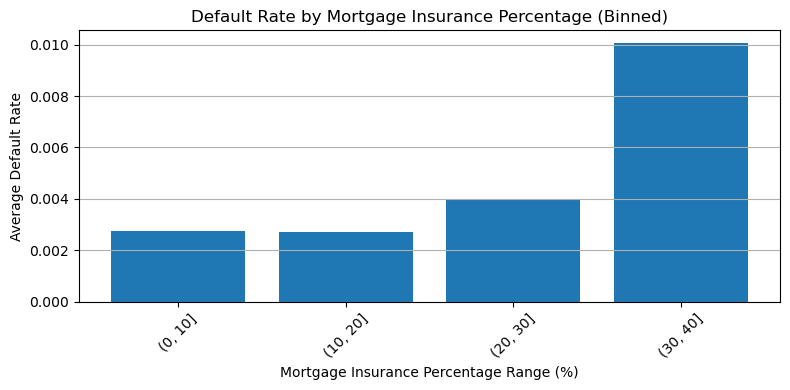

In [26]:
# Bin mortgage insurance percentage into intervals of 5%
final_df['mi_bin'] = pd.cut(final_df['mortgage_insurance_percentage'], bins = range(0, 60, 10))  # e.g., 0-5%, 5-10%, ..., 55-60%

# Group by bins and calculate average default rate
mi_hist = final_df.groupby('mi_bin')['delinquency_flag'].mean().reset_index()

# Plotting
plt.figure(figsize = (8, 4))
plt.bar(mi_hist['mi_bin'].astype(str), mi_hist['delinquency_flag'])
plt.xticks(rotation = 45)
plt.title('Default Rate by Mortgage Insurance Percentage (Binned)')
plt.xlabel('Mortgage Insurance Percentage Range (%)')
plt.ylabel('Average Default Rate')
plt.tight_layout()
plt.grid(axis = 'y')
plt.show()



<h5>Analysis: As the Mortgage Insurance Percentage increases, the default rate increases.</h5>

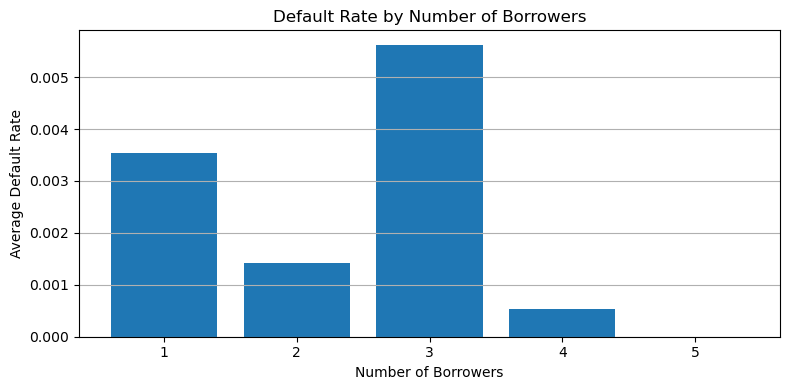

In [25]:
# Group by number of borrowers and calculate average default rate
borrower_hist = final_df.groupby('num_borrowers')['delinquency_flag'].mean().reset_index()

# Plotting
plt.figure(figsize = (8, 4))
plt.bar(borrower_hist['num_borrowers'].astype(str), borrower_hist['delinquency_flag'])
plt.title('Default Rate by Number of Borrowers')
plt.xlabel('Number of Borrowers')
plt.ylabel('Average Default Rate')
plt.tight_layout()
plt.grid(axis = 'y')
plt.show()

<h5>Analysis: The order from highest default rate to lowest default rate is 3, 1, 2, 4</h5>

In [13]:
min_value = final_df['dti'].min()
max_value = final_df['dti'].max()
print("The Min Value",min_value)
print("The Max Value",max_value)
final_df.info()

The Min Value 1
The Max Value 999
<class 'pandas.core.frame.DataFrame'>
Index: 1913039 entries, 1164015 to 665904
Data columns (total 15 columns):
 #   Column                         Dtype   
---  ------                         -----   
 0   Loan_Sequence_Number           object  
 1   Monthly_Reporting_Period       int64   
 2   Current_Actual_UPB             float64 
 3   credit_score                   int64   
 4   cltv_score                     int64   
 5   dti                            int64   
 6   interest_rate                  float64 
 7   mortgage_insurance_percentage  int64   
 8   num_borrowers                  int64   
 9   delinquency_flag               int64   
 10  dti_bin                        category
 11  cltv_bin                       category
 12  credit_score_bin               category
 13  interest_rate_bin              category
 14  mi_bin                         category
dtypes: category(5), float64(2), int64(7), object(1)
memory usage: 169.7+ MB


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Feature engineering - Select features required for ML Model
features = ['credit_score', 'cltv_score', 'dti', 'interest_rate','mortgage_insurance_percentage', 'num_borrowers','delinquency_flag']
ml_df = final_df[features]

# Example preprocessing steps (adapt to your specific features)
# Assuming 'target' is your loan default variable (1 for default, 0 for no default)
cleaned_df = ml_df.dropna()
X = cleaned_df.drop('delinquency_flag', axis = 1)
y = cleaned_df['delinquency_flag']

# Handle categorical features (example with LabelEncoder, but OneHotEncoder might be preferred)
for column in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])

# Handle numerical features (example with StandardScaler)
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Address class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Example using Logistic Regression
model = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate performance
print(classification_report(y_test, y_pred))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba)}')


              precision    recall  f1-score   support

           0       0.77      0.73      0.75    381887
           1       0.74      0.79      0.76    381349

    accuracy                           0.76    763236
   macro avg       0.76      0.76      0.76    763236
weighted avg       0.76      0.76      0.76    763236

ROC AUC: 0.8265170420397746


In [15]:
# Test Data Input:
# this results true(1) - 688	95	42	2.500
# this results in false(0) - 761	56	50	2.750
# This result in false(0) - 722	89	40	2.875

# New Test Data
# This result is false(0) - 741	76	23	3.125	0	1
# This result is true(1) - 699	78	50	2.500	0	1

Predicted default status: 0
Probability of default: 25.77%
Low risk of default. Keep maintaining good financial habits.

Feature-based advice:

 * Number of borrowers is 3.0, which may introduce more complexity to the loan. 
Consider any of the following steps to strengthen your loan profile:
 1) Ensure all borrowers have solid credit scores and stable income - lenders may focus on the weakest profile.
 2) If any borrower has poor credit or low income, explore whether they can be removed from the application.
 3) Clearly define financial responsibilities among borrowers to prevent confusion or missed payments.



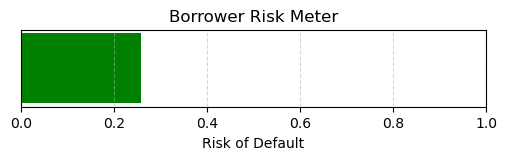

In [41]:
# --- Importing necessary libraries ---
import pandas as pd                      # For data manipulation and creating dataframes
import matplotlib.pyplot as plt          # For plotting the risk meter
from sklearn.preprocessing import LabelEncoder, StandardScaler  # For data preprocessing
from sklearn.linear_model import LogisticRegression             # For building a prediction model
import joblib                            # For loading saved machine learning models or scalers

# --- Input area ---
# Creating a new input DataFrame with borrower financial features
original_input = pd.DataFrame([{
    'credit_score': 700,      # High credit score (good)
    'cltv_score': 78,         # Combined Loan-To-Value ratio
    'dti': 39,                # Debt-To-Income ratio
    'interest_rate': 2.9,      # Interest rate on the loan
    'mortgage_insurance_percentage': 20, 
    'num_borrowers': 3
}])

# --- Preprocessing ---
# Making a copy of the original input to avoid changing it
new_data = original_input.copy()

# Selecting numerical columns to standardize them
numerical_cols = new_data.select_dtypes(include=['int64', 'float64']).columns

# Standardizing numerical values using a pre-fitted scaler (assumes 'scaler' was defined elsewhere)
new_data[numerical_cols] = scaler.transform(new_data[numerical_cols])  

# --- Prediction ---
# Using a pre-trained model (assumes 'model' was defined or loaded before) to make predictions
prediction = model.predict(new_data)                  # Predicts default status (e.g., 0 or 1)
prediction_proba = model.predict_proba(new_data)[:, 1]  # Gets probability of default (class 1)
risk_score = prediction_proba[0]                       # Extracts the probability value

# Displays the prediction results
print(f"Predicted default status: {prediction[0]}")
print(f"Probability of default: {risk_score:.2%}")

# --- Risk Band Classification ---
# Classifies the risk score into High, Moderate, or Low risk
if risk_score >= 0.6:
    risk_level = "High"
elif risk_score >= 0.3:
    risk_level = "Moderate"
else:
    risk_level = "Low"

# --- Risk Message ---
# Prints advice or warnings based on the risk level
if risk_level == "High":
    print("High risk of loan default detected. Immediate financial review recommended.")
elif risk_level == "Moderate":
    print("Moderate risk of default. You're not in danger, but some indicators raise concern.")
else:
    print("Low risk of default. Keep maintaining good financial habits.")

# --- Feature Influence Explanation ---
print("\nFeature-based advice:\n")

# Extracts the values from the input row to evaluate them individually
vals = original_input.iloc[0]

# Sees if advice was given
advice_given = False

# Gives personalized advice based on individual feature values
if vals['dti'] > 43:
    advice_given = True
    print(f" * DTI of {vals['dti']:.2f} is high. \n Consider any of the following steps to improve your DTI score:\n 1) Create a detailed monthly budget to track and control non-essential spending.\n 2) Pay down high-interest credit cards first to reduce monthly obligations.\n 3) Consider a side income stream, such as freelance work, part-time gigs, or selling unused items.\n")

if vals['interest_rate'] > 3.5:
    advice_given = True
    print(f" * Interest rate of {vals['interest_rate']:.2f}% is above average. Consider any of the following steps to lower your interest rate:\n 1) Refinancing your loan with another lender offering better terms — especially if your credit score has improved.\n 2) Shopping around and comparing at least 3–5 lenders to find the lowest available interest rates.\n 3) Increasing your down payment or reducing loan amount if possible, as this can qualify you for better rates.\n")

if vals['cltv_score'] > 80:
    advice_given = True
    print(f" * CLTV score of {vals['cltv_score']:.0f} suggests low equity. Consider any of the following steps to improve your CLTV score:\n 1) Making a larger down payment to lower the loan amount relative to the property value.\n 2) Paying down existing second liens or home equity loans to reduce the combined balance. \n 3) Waiting to borrow until your property value appreciates, improving the ratio in your favor.\n")

if vals['credit_score'] < 700:
    advice_given = True
    print(f" * Credit score of {vals['credit_score']:.0f} is below ideal. Consider any of the following steps to improve your credit score:\n 1) Paying all bills on time, including credit cards, loans, and utilities.\n 2) Reducing credit card balances to below 30% of your limit to improve credit utilization.\n 3) Avoiding new hard inquiries or unnecessary new credit accounts, which can temporarily lower your score.\n")

if vals['mortgage_insurance_percentage'] > 30:
    advice_given = True
    print(f" * Mortgage insurance percentage of {vals['mortgage_insurance_percentage']:.1f}% is high. Consider any of the following steps to improve your mortgage insurance percentage:\n 1) Explore options for a higher down payment to reduce loan-to-value (LTV) ratio.\n 2) Refinance your mortgage if your home value has increased and your credit has improved.\n 3) Shop around for different lenders or insurance providers to find more competitive MI rates.\n")

if vals['num_borrowers'] > 2:
    advice_given = True
    print(f" * Number of borrowers is {vals['num_borrowers']}, which may introduce more complexity to the loan. \nConsider any of the following steps to strengthen your loan profile:\n 1) Ensure all borrowers have solid credit scores and stable income - lenders may focus on the weakest profile.\n 2) If any borrower has poor credit or low income, explore whether they can be removed from the application.\n 3) Clearly define financial responsibilities among borrowers to prevent confusion or missed payments.\n")

if not advice_given:
    print("None – all financial indicators are within healthy ranges.")
    
# --- Visual Risk Meter ---
# Creates a horizontal bar to visually represent the risk of default
plt.figure(figsize=(6, 1))  # Defines the size of the plot
bar_color = 'green' if risk_score < 0.3 else ('orange' if risk_score < 0.6 else 'red')  # Sets bar color by risk
plt.barh([0], [risk_score], color=bar_color)  # Draws horizontal bar showing risk score
plt.xlim(0, 1)  # Sets the scale of the x-axis from 0 to 1 (probability scale)
plt.yticks([])  # Hides y-axis ticks for cleaner look
plt.xlabel("Risk of Default")  # Label for x-axis
plt.title("Borrower Risk Meter")  # Title of the chart
plt.grid(True, axis='x', linestyle='--', alpha=0.5)  # Adds dashed grid lines to x-axis
plt.show()  # Displays the plot.